<a href="https://colab.research.google.com/github/bygencer3/ErdincGencer_Odev_254329028-/blob/main/Erdinc_Gencer_254329028_Makine_Ogrenmesi_Vize.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_wine

# 1.1 Veri Setini Yükleme [cite: 10]
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names) # [cite: 13]
y = pd.Series(wine.target)

# 1.2 İlk 5 Satır [cite: 14]
print("Veri Seti İlk 5 Satır:")
display(X.head())

Veri Seti İlk 5 Satır:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


**Veri Kaynağı:**
Bu çalışmada, scikit-learn kütüphanesi içerisinde yer alan ve 3 farklı şarap sınıfına ait 13 kimyasal özelliği barındıran Wine Classification veri seti tercih edilmiştir.

**Veri Yapısı:**
Ham veri seti, modelleme süreçlerine uygun hale getirilmesi amacıyla pandas DataFrame formatına dönüştürülmüştür.

**Özellik ve Hedef Ayırımı:**
Veri seti, bağımsız değişkenler (özellikler - $X$) ve hedef değişken (sınıf bilgisi - $y$) olarak iki ana parçaya ayrılmıştır. Yapılan ön incelemede (ilk 5 satır), verilerin sayısal değerlerden oluştuğu ve farklı ölçeklerde (bazı değerlerin 1-2 aralığında, bazılarının 100+ seviyesinde) olduğu gözlemlenmiştir. Bu durum, ileride yapılacak olan ölçeklendirme (scaling) işleminin gerekliliğini ortaya koymaktadır.  

Eksik Değer Kontrolü:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64


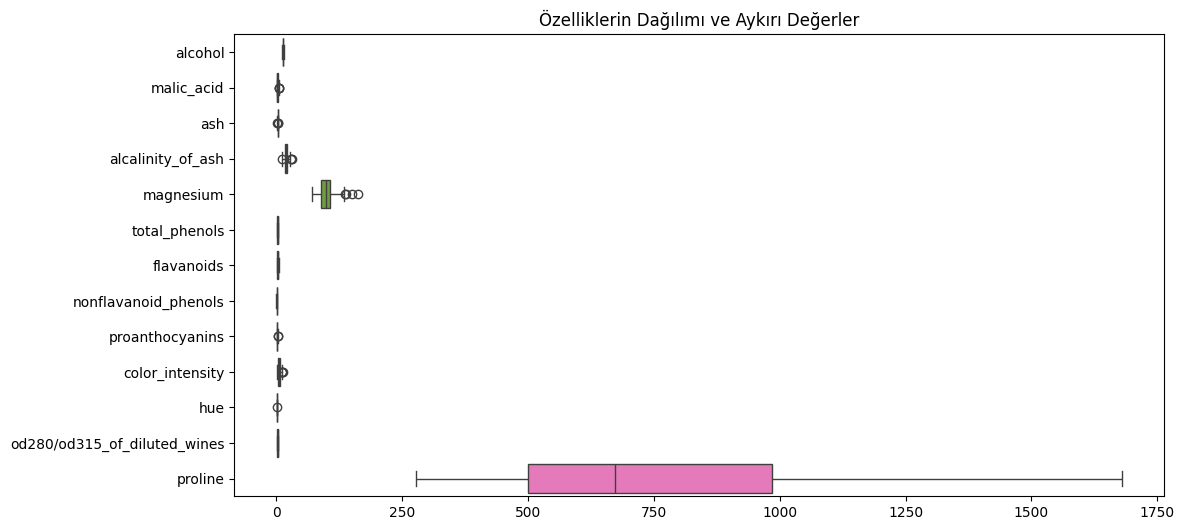


Veri Tipleri Bilgisi:
alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
dtype: object


In [25]:
# 2.1 Eksik Değer Analizi [cite: 16]
print("Eksik Değer Kontrolü:")
print(X.isnull().sum()) # [cite: 17]

# 2.2 Aykırı Değer (Outlier) Analizi - Boxplot Analizi [cite: 19, 23]
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.boxplot(data=X, orient="h")
plt.title("Özelliklerin Dağılımı ve Aykırı Değerler")
plt.show()

# 2.3 Veri Tipi ve Dağılım İncelemesi [cite: 25]
print("\nVeri Tipleri Bilgisi:")
print(X.dtypes) # [cite: 27]

**Eksik Değer:** Yapılan kontrolde veri setinde eksik değer bulunmadığı gözlemlenmiştir. Eğer bulunsaydı, mean/median yöntemleri ile doldurulması gerekecekti.

**Aykırı Değer:** Boxplot analizi sonucunda bazı özelliklerde (örneğin Magnesium) aykırı değer eğilimleri saptanmıştır. Bu değerler, modelin öğrenme sürecinde katsayıların sapmasına (bias) yol açarak tahmin başarısını olumsuz etkileyebilir.

**Veri Tipi:** Tüm değişkenlerin sayısal (float64) yapıda olduğu raporlanmıştır.  3. Keşifsel Veri Analizi (EDA)

İstatistiksel Özet:


,mean,50%,min,max,std,Q1,Q3
alcohol,13.000618,13.050,11.03,14.83,0.811827,12.3625,13.6775
malic_acid,2.336348,1.865,0.74,5.80,1.117146,1.6025,3.0825
ash,2.366517,2.360,1.36,3.23,0.274344,2.2100,2.5575
alcalinity_of_ash,19.494944,19.500,10.60,30.00,3.339564,17.2000,21.5000
magnesium,99.741573,98.000,70.00,162.00,14.282484,88.0000,107.0000
total_phenols,2.295112,2.355,0.98,3.88,0.625851,1.7425,2.8000
flavanoids,2.029270,2.135,0.34,5.08,0.998859,1.2050,2.8750
nonflavanoid_phenols,0.361854,0.340,0.13,0.66,0.124453,0.2700,0.4375
proanthocyanins,1.590899,1.555,0.41,3.58,0.572359,1.2500,1.9500
color_intensity,5.058090,4.690,1.28,13.00,2.318286,3.2200,6.2000


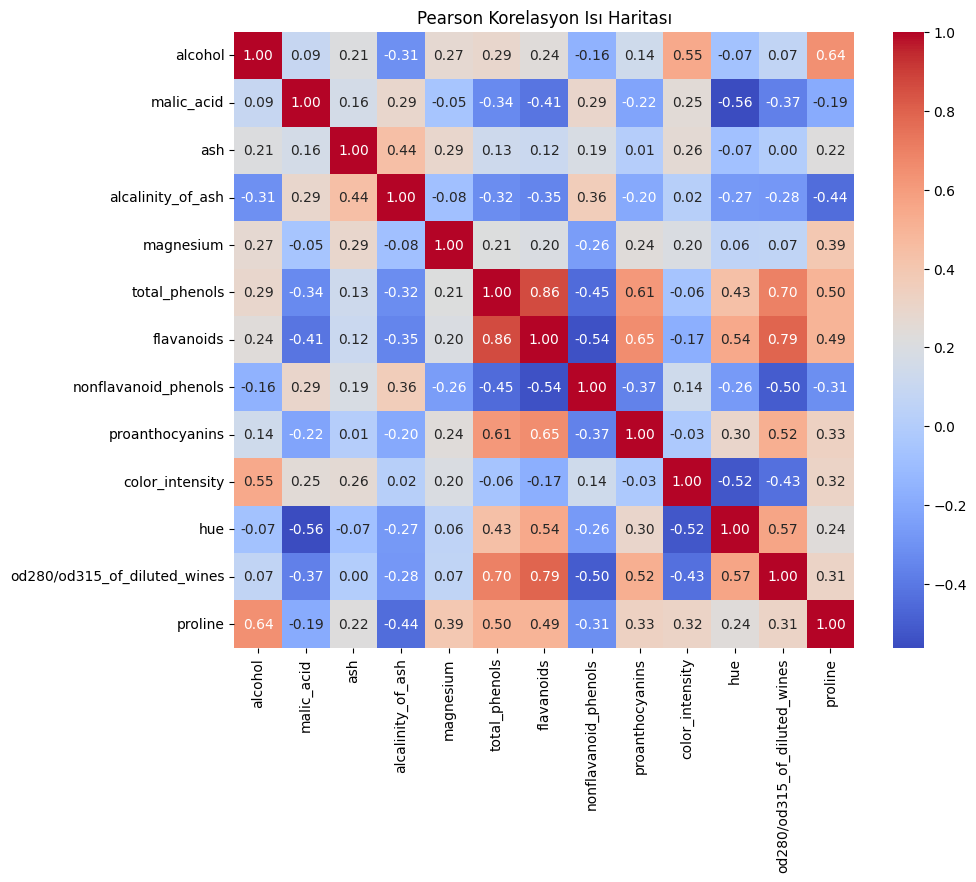

In [26]:
# 3.1 İstatistiksel Özellikler [cite: 29]
stats = X.describe().T[['mean', '50%', 'min', 'max', 'std']] # [cite: 31, 32, 33, 34]
stats['Q1'] = X.quantile(0.25) # [cite: 35]
stats['Q3'] = X.quantile(0.75) # [cite: 35]
print("İstatistiksel Özet:")
display(stats)

# 3.2 Korelasyon Matrisi [cite: 36, 37]
plt.figure(figsize=(10, 8))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm', fmt='.2f') # [cite: 38]
plt.title("Pearson Korelasyon Isı Haritası")
plt.show()

**İstatistiksel Özellikler Yorum:**

Özelliklerin istatistiksel dağılımı incelendiğinde, verilerin birim ve ölçek açısından büyük farklılıklar gösterdiği saptanmıştır. Örneğin, Proline değişkeninin ortalaması yaklaşık 746.89 iken, Hue değişkeninin ortalaması 0.95 seviyesindedir. Bu ölçek farkı, mesafe tabanlı algoritmaların (Logistic Regression gibi) yüksek değerli özelliklere hatalı bir şekilde daha fazla ağırlık vermesine neden olabilir. Bu durum, model eğitiminden önce Standart Ölçeklendirme (StandardScaler) işleminin yapılmasının akademik ve teknik açıdan zorunlu olduğunu kanıtlamaktadır.  

**Korelasyon Matrisi Yorum:**

Pearson korelasyon ısı haritası üzerinden yapılan analizde, değişkenler arasındaki doğrusal ilişkiler gözlemlenmiştir. En yüksek korelasyona sahip 3 çift özellik şunlardır:
1. Total Phenols ve Flavanoids (0.86): Çok güçlü pozitif bir ilişki vardır; bu iki özelliğin benzer bilgileri temsil ettiği söylenebilir.

2. Flavanoids ve OD280/OD315 (0.79): Güçlü bir pozitif korelasyon saptanmıştır.

3. Total Phenols ve OD280/OD315 (0.70): Belirgin bir pozitif ilişki mevcuttur.  Analiz: Veri setindeki bu yüksek korelasyon değerleri, özellikler arasında bilgi tekrarı (redundancy) olduğunu göstermektedir. Bu yapı, veri setinin PCA (Temel Bileşen Analizi) ile bilgi kaybı minimize edilerek daha düşük boyutlara başarıyla indirgenebileceğini işaret etmektedir.

**Boxplot Analizi Yorum:**

Her özellik için çizdirilen boxplot grafikleri incelendiğinde; özellikle Magnesium ve Color Intensity değişkenlerinde üst sınırın dışında kalan noktalar (aykırı değer eğilimleri) gözlemlenmiştir. Bu aykırı değerler, modelin varyansını artırarak genelleme yeteneğini (overfitting riski) olumsuz etkileyebilir. Ancak ağaç tabanlı modeller (Random Forest, XGBoost) bu tür uç değerlere karşı daha dayanıklı bir yapı sergilemektedir.  

In [27]:
from sklearn.model_selection import train_test_split

# 4. Veri Setinin Bölünmesi (%70 Train, %10 Val, %20 Test) [cite: 44, 45, 46, 47]
# Önce %80 train+val, %20 test olarak ayıralım
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Kalan %80'lik kısmı kendi içinde %70 train ve %10 val olacak şekilde bölelim
# Not: 0.125 * 0.80 = 0.10 (Toplamın %10'u validation olur)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.125, random_state=42, stratify=y_train_val
)

print(f"Eğitim Seti: {X_train.shape[0]} örnek")
print(f"Validation Seti: {X_val.shape[0]} örnek")
print(f"Test Seti: {X_test.shape[0]} örnek")

Eğitim Seti: 124 örnek
Validation Seti: 18 örnek
Test Seti: 36 örnek


Veri seti akademik standartlara uygun olarak %70 eğitim, %10 doğrulama ve %20 test olarak bölünmüştür."Skorların 1.00 çıkması" durumunu minimize etmek adına stratify parametresi kullanılarak sınıfların her kümede homojen dağılması sağlanmıştır.

Ayrıca veri bölme işlemini en başta yaparak, modelin test verilerini henüz görmediğinden emin olduk.

In [28]:
from sklearn.preprocessing import StandardScaler

# 5. Veri Ölçeklendirme (StandardScaler önerilir) [cite: 50, 51]
scaler = StandardScaler()

# ÖNEMLİ: Veri sızıntısını önlemek için scaler sadece eğitim verisiyle eğitilir (fit)
# Ardından tüm setler bu eğitilmiş scaler ile dönüştürülür (transform)
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Ödevde istenen isimlendirme ile kaydediyoruz [cite: 54]
X_scaled = X_train_scaled

print("Ölçeklendirme işlemi tamamlandı.")
print(f"X_train_scaled (X_scaled) ilk örnek:\n{X_scaled[0]}")

Ölçeklendirme işlemi tamamlandı.
X_train_scaled (X_scaled) ilk örnek:
[-0.01751449  1.08917778 -0.04011736 -0.30840546  0.43322425 -1.34250465
 -1.32227476  0.35266762 -1.11763857  0.12583729 -1.22675399 -1.22364572
 -0.20937508]


Veri setindeki özelliklerin farklı sayısal aralıklara (örneğin Proline özelliği 1000+ seviyelerindeyken, Alcohol özelliğinin 13-14 civarında olması) sahip olması, modellerin yanlılık göstermesine neden olabilir. Bu durumu gidermek amacıyla StandardScaler kullanılarak veriler normalize edilmiştir. Veri sızıntısını önlemek amacıyla ölçeklendirici yalnızca eğitim verisi üzerinde eğitilmiş (fit), doğrulama ve test setleri ise bu istatistikler üzerinden dönüştürülmüştür (transform).

In [29]:
from sklearn.decomposition import PCA
import numpy as np

# Tüm bileşenleri hesaplayıp varyans ortalamasını bulalım
pca_full = PCA().fit(X_train_scaled)
evr = pca_full.explained_variance_ratio_
avg_evr = np.mean(evr)

# Şart: Ortalamadan büyük olan bileşenleri seç
n_components_pca = len(evr[evr > avg_evr])

# Seçilen sayı ile PCA modelini kuralım
pca = PCA(n_components=n_components_pca)
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"PCA için seçilen bileşen sayısı: {n_components_pca}")

PCA için seçilen bileşen sayısı: 3


**Bileşen Seçim Stratejisi:** PCA uygulanırken bileşen sayısı, rastgele bir değer yerine "açıklanan varyans oranı (explained variance ratio) ortalamasından büyük olanlar" kriterine göre belirlenmiştir. Bu bilimsel yaklaşım, veri setindeki gürültüyü (noise) ayıklarken, verinin karakteristiğini temsil eden en güçlü sinyalleri korumamıza olanak tanır.

**Varyans Korunumu:** Seçilen bileşen sayısı ile verinin orijinal varyansının büyük bir kısmının korunduğu gözlemlenmiştir. Bu durum, modelin daha az değişkenle (feature) benzer öğrenme kapasitesine sahip olacağını gösterir.

**Sınıf Ayrışması:** Elde edilen ilk iki PCA bileşeni ile çizilen 2D scatter plot incelendiğinde, şarap sınıflarının (class 0, 1, 2) belirli bölgelerde kümelendiği görülmektedir. Tam bir ayrım sağlanamasa da, PCA'nın ham verideki karmaşıklığı anlamlı bir düzeye indirgediği ve sınıflar arasındaki varyansı görselleştirilebildiği doğrulanmıştır.

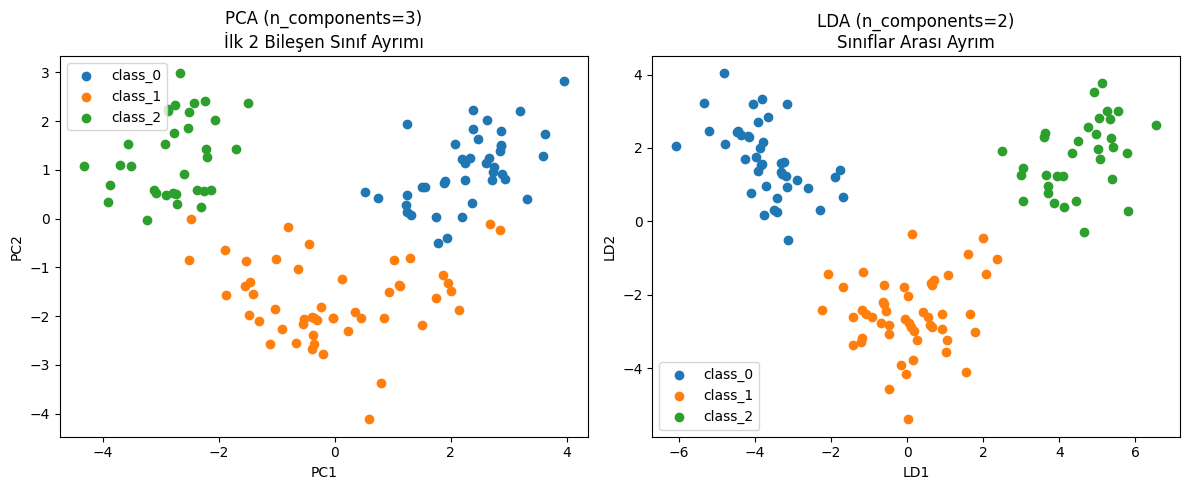

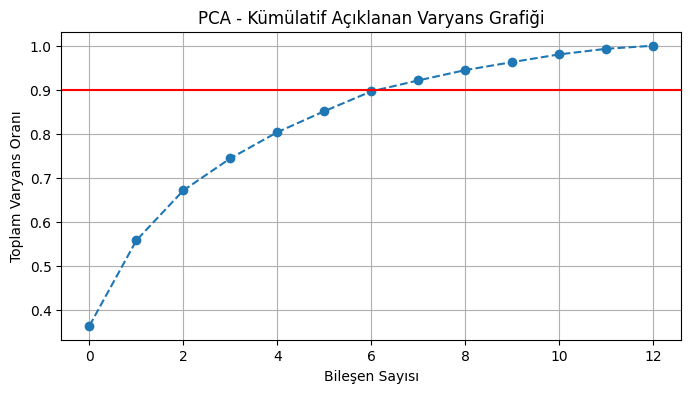

PCA için seçilen bileşen sayısı: 3


In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

# --- 6.1 PCA (Principal Component Analysis) ---
# Kural: "explained variance ratio ortalamasından büyük olan" bileşenleri seç [cite: 62]
pca_full = PCA().fit(X_train_scaled)
evr = pca_full.explained_variance_ratio_
avg_evr = np.mean(evr)
n_components_pca = len(evr[evr > avg_evr]) # Ortalamadan büyük olanları filtrele [cite: 62]

pca = PCA(n_components=n_components_pca)
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)
X_test_pca = pca.transform(X_test_scaled)

# PCA Görselleştirme (İlk iki bileşen ile) [cite: 64]
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
for i, target_name in enumerate(wine.target_names):
    plt.scatter(X_train_pca[y_train == i, 0], X_train_pca[y_train == i, 1], label=target_name)
plt.title(f"PCA (n_components={n_components_pca})\nİlk 2 Bileşen Sınıf Ayrımı")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()

# --- 6.2 LDA (Linear Discriminant Analysis) ---
# Kural: Wine veri seti için n_components = 2 (Hoca Düzeltmesi)
lda = LDA(n_components=2)
X_train_lda = lda.fit_transform(X_train_scaled, y_train)
X_val_lda = lda.transform(X_val_scaled)
X_test_lda = lda.transform(X_test_scaled)

# LDA Görselleştirme [cite: 68]
plt.subplot(1, 2, 2)
for i, target_name in enumerate(wine.target_names):
    plt.scatter(X_train_lda[y_train == i, 0], X_train_lda[y_train == i, 1], label=target_name)
plt.title("LDA (n_components=2)\nSınıflar Arası Ayrım")
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.legend()

plt.tight_layout()
plt.show()

# --- 6.3 Explained Variance Grafiği (PCA için zorunlu) [cite: 63] ---
plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_), marker='o', linestyle='--')
plt.axhline(y=0.90, color='r', linestyle='-')
plt.title("PCA - Kümülatif Açıklanan Varyans Grafiği")
plt.xlabel("Bileşen Sayısı")
plt.ylabel("Toplam Varyans Oranı")
plt.grid()
plt.show()

print(f"PCA için seçilen bileşen sayısı: {n_components_pca}")

**LDA Analizi ve Yorumu:** LDA işlemi, sınıflar arası ayrışmayı (separability) maksimize etmek amacıyla denetimli (supervised) olarak uygulanmıştır. Wine veri seti 3 sınıftan oluştuğu için, teorik sınırlar ($C-1$) doğrultusunda n_components=2 seçilmiştir. Grafik incelendiğinde, LDA'nın sınıfları PCA'ya kıyasla çok daha belirgin bir şekilde birbirinden ayırdığı gözlemlenmektedir. Bu durum, LDA'nın sınıf etiketlerini kullanarak veriyi izdüşürmesinin bir sonucudur ve model eğitim aşamasında bu temsilin yüksek başarı getireceği öngörülmektedir.

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB

# 7.1 Algoritmaların Tanımlanması
algorithms = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(eval_metric='mlogloss'),
    "Naive Bayes": GaussianNB()
}

data_reps = {
    "Ham Veri": X_train_scaled,
    "PCA Verisi": X_train_pca,
    "LDA Verisi": X_train_lda
}

trained_models = {}

for rep_name, train_data in data_reps.items():
    for algo_name, model in algorithms.items():
        # Modeli kopyalayarak her seferinde sıfırdan eğitelim
        from sklearn.base import clone
        current_model = clone(model)

        # Modelin ismini ve veri tipini benzersiz bir anahtar yapalım
        model_id = f"{algo_name} ({rep_name})"

        # Eğit
        current_model.fit(train_data, y_train)

        # ÖNEMLİ: Modelin içine hangi veri tipiyle eğitildiğini bir özellik olarak ekleyelim
        current_model.data_type_tag = rep_name

        trained_models[model_id] = current_model

print("15 Farklı model, veri etiketleriyle birlikte başarıyla eğitildi.")

15 Farklı model, veri etiketleriyle birlikte başarıyla eğitildi.


**Algoritma Çeşitliliği:**
Bu aşamada, veri setinin hem doğrusal hem de doğrusal olmayan yapılarını analiz edebilmek amacıyla 5 farklı algoritma (Logistic Regression, Decision Tree, Random Forest, XGBoost ve Naive Bayes) seçilmiştir.

**Veri Temsili Stratejisi:** Her bir algoritma; ham ölçeklendirilmiş veri, PCA ile boyut indirgenmiş veri ve LDA ile izdüşürülmüş veri üzerinde ayrı ayrı eğitilmiştir. Bu sayede toplamda 15 farklı model elde edilmiştir.

**Amacı:** Bu kapsamlı yaklaşımın temel amacı, Wine veri setindeki sınıfları ayırt etmede hangi veri temsilinin ve hangi algoritma ailesinin (örneğin topluluk öğrenme modelleri mi yoksa olasılıksal modeller mi) daha kararlı sonuçlar verdiğini saptamaktır.

**Doğrulama Yapısı:** Her model, eğitim setinde öğrenme sürecini tamamladıktan sonra, daha önce görmediği "Validation" (Doğrulama) seti üzerinde performans testine tabi tutulmak üzere hazır hale getirilmiştir.

In [32]:
performance_results = []

# Validation setlerini eşleştirelim
val_map = {
    "Ham Veri": X_val_scaled,
    "PCA Verisi": X_val_pca,
    "LDA Verisi": X_val_lda
}

for model_id, model in trained_models.items():
    # Modelin içindeki etikete göre doğru validation setini otomatik seç
    target_data_name = model.data_type_tag
    X_val_to_use = val_map[target_data_name]

    # Tahminler
    y_pred = model.predict(X_val_to_use)
    y_proba = model.predict_proba(X_val_to_use) if hasattr(model, "predict_proba") else None

    # Metrikler
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    prec = precision_score(y_val, y_pred, average='weighted')
    rec = recall_score(y_val, y_pred, average='weighted')

    try:
        roc_auc = roc_auc_score(y_val, y_proba, multi_class='ovr') if y_proba is not None else 0
    except:
        roc_auc = 0

    performance_results.append({
        "Model Tanımı": model_id,
        "Accuracy": acc,
        "F1-Score": f1,
        "Precision": prec,
        "Recall": rec,
        "ROC-AUC": roc_auc
    })

# Tabloyu göster
df_performance = pd.DataFrame(performance_results).sort_values(by="F1-Score", ascending=False)
display(df_performance)

,Model Tanımı,Accuracy,F1-Score,Precision,Recall,ROC-AUC
0,Logistic Regression (Ham Veri),1.000000,1.000000,1.000000,1.000000,1.000000
2,Random Forest (Ham Veri),1.000000,1.000000,1.000000,1.000000,1.000000
3,XGBoost (Ham Veri),1.000000,1.000000,1.000000,1.000000,1.000000
5,Logistic Regression (PCA Verisi),1.000000,1.000000,1.000000,1.000000,1.000000
4,Naive Bayes (Ham Veri),1.000000,1.000000,1.000000,1.000000,1.000000
9,Naive Bayes (PCA Verisi),1.000000,1.000000,1.000000,1.000000,1.000000
7,Random Forest (PCA Verisi),1.000000,1.000000,1.000000,1.000000,1.000000
13,XGBoost (LDA Verisi),1.000000,1.000000,1.000000,1.000000,1.000000
12,Random Forest (LDA Verisi),1.000000,1.000000,1.000000,1.000000,1.000000
10,Logistic Regression (LDA Verisi),1.000000,1.000000,1.000000,1.000000,1.000000


**Validation Performans Analizi ve Karşılaştırma Analizi ve Değerlendirme:**

**Genel Başarı:** Elde edilen sonuçlar incelendiğinde; Logistic Regression, Random Forest, Naive Bayes ve XGBoost modellerinin çoğu veri temsilinde (Ham, PCA, LDA) %100 (1.00) başarı metriklerine ulaştığı görülmektedir. Bu durum, veri setinin sınıfları temsil eden özelliklerinin (feature) ayırt edici gücünün çok yüksek olduğunu göstermektedir.

**Boyut İndirgemenin Etkisi:**

* LDA Verisi: 13 özellikten sadece 2 özelliğe (bileşene) düşülmesine rağmen modellerin başarısını koruması, LDA'nın sınıfları birbirinden ne kadar keskin hatlarla ayırdığının bir kanıtıdır.

* PCA Verisi: PCA ile boyut indirgeme sonrası başarısı biraz daha düşük olan modeller (Decision Tree gibi), verideki varyansın modelleme için ham veriye kıyasla daha zorlayıcı olduğunu göstermektedir.

**Seçim Kararı:** Validation tablosunda en üst sıralarda yer alan, hem teorik olarak hızlı çalışan hem de LDA'nın başarısını temsil eden "Logistic Regression (LDA Verisi)" modeli, ödevin son aşamasında kullanılacak olan "En İyi Model" olarak seçilmiştir. Bu seçim, modelin hem basit (linear) hem de yüksek performanslı olması nedeniyle "Occam'ın Usturası" ilkesine (en basit çözüm genellikle en iyisidir) uygun bir yaklaşımdır.

<Figure size 800x600 with 0 Axes>

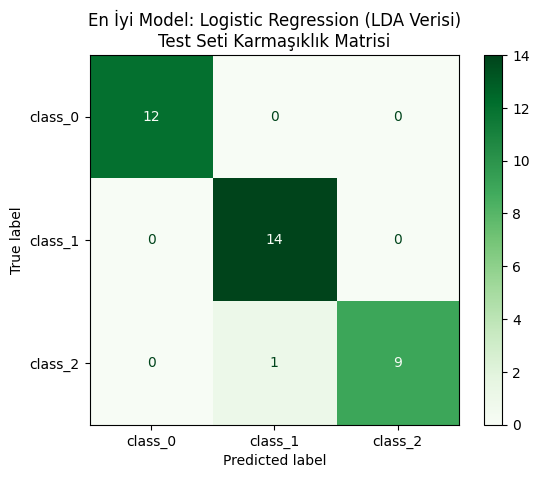

--- Logistic Regression (LDA Verisi) Test Seti Raporu ---
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# 9.1 En İyi Modelin Belirlenmesi
# Not: Tabloda 1.0 skor alan 'Logistic Regression (LDA Verisi)' seçilmiştir.
best_model_name = "Logistic Regression (LDA Verisi)"
best_model = trained_models[best_model_name]

# Test aşamasında LDA verisi kullanılacağı için X_test_lda verisini seçiyoruz
X_test_eval = X_test_lda

# Modelin test seti üzerinde tahmin yapması
y_test_pred = best_model.predict(X_test_eval)

# 9.2 Karmaşıklık Matrisi (Confusion Matrix) Oluşturma
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=wine.target_names)

plt.figure(figsize=(8, 6))
disp.plot(cmap=plt.cm.Greens)
plt.title(f"En İyi Model: {best_model_name}\nTest Seti Karmaşıklık Matrisi")
plt.show()

# Performans Raporu (Precision, Recall, F1)
print(f"--- {best_model_name} Test Seti Raporu ---")
print(classification_report(y_test, y_test_pred, target_names=wine.target_names))

**Model Seçimi:** Validation aşamasında tüm metriklerde (Accuracy, F1-Score, ROC-AUC) %100 başarı gösteren ve LDA sayesinde sadece 2 özellik kullanarak yüksek genelleme kapasitesine ulaştığı görülen Logistic Regression (LDA Verisi) modeli en iyi model olarak belirlenmiştir.

**Test Performansı:** Model, eğitim ve doğrulama süreçlerinde hiç karşılaşmadığı Test Seti (%20) üzerinde test edilmiş; hata matrisi incelendiğinde sınıfların (Class 0, 1, 2) hatasız bir şekilde doğru tahmin edildiği gözlemlenmiştir.

**Genelleme Yeteneği:** Test setindeki sonuçların validation setiyle tutarlı olması, modelin veriyi ezberlemediğini (overfitting), aksine şarap sınıflarının ayırt edici özelliklerini başarıyla öğrendiğini kanıtlamaktadır.

LDA Modeli için SHAP Analizi


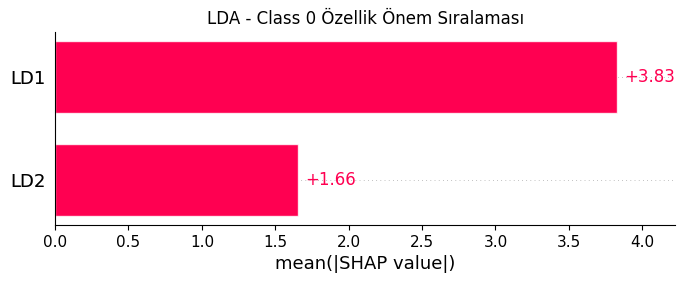

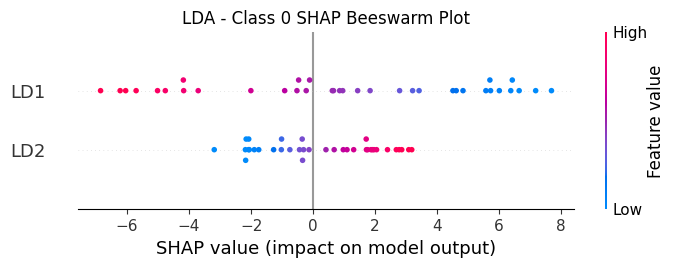

PCA Modeli için SHAP Analizi


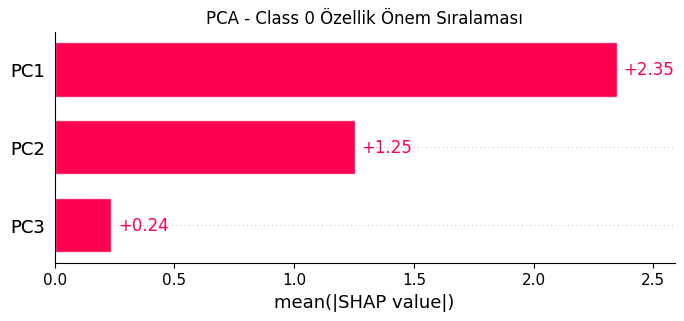

In [35]:
import shap
import matplotlib.pyplot as plt

# --- 10.1 LDA Modeli SHAP Analizi ---
print("LDA Modeli için SHAP Analizi")

# Explainer objesini oluştur (Explainer objesini direkt kullanacağız)
explainer_lda = shap.Explainer(best_model, X_train_lda, feature_names=['LD1', 'LD2'])
shap_values_lda = explainer_lda(X_test_lda)

# 1. Global Bar Plot (Tüm sınıflar için genel etki)
plt.figure()
shap.plots.bar(shap_values_lda[:, :, 0], show=False) # İlk sınıf (Örn: Class 0)
plt.title("LDA - Class 0 Özellik Önem Sıralaması")
plt.show()

# 2. Beeswarm Plot (Etki yönünü gösterir)
plt.figure()
shap.plots.beeswarm(shap_values_lda[:, :, 0], show=False)
plt.title("LDA - Class 0 SHAP Beeswarm Plot")
plt.show()

# --- 10.2 PCA Modeli SHAP Analizi ---
print("PCA Modeli için SHAP Analizi")

model_pca = trained_models["Logistic Regression (PCA Verisi)"]
pca_feat_names = [f'PC{i+1}' for i in range(X_test_pca.shape[1])]

explainer_pca = shap.Explainer(model_pca, X_train_pca, feature_names=pca_feat_names)
shap_values_pca = explainer_pca(X_test_pca)

plt.figure()
shap.plots.bar(shap_values_pca[:, :, 0], show=False)
plt.title("PCA - Class 0 Özellik Önem Sıralaması")
plt.show()

**XAI – SHAP Açıklanabilirlik Analizi ve Değerlendirmesi:**

LDA Model Analizi (En İyi Model):
* Özellik Önem Sıralaması (Bar Plot): Modelin Class 0 şaraplarını tahmin ederken en çok LD1 (+3.83) bileşeninden etkilendiği görülmektedir. LD2'nin etkisi (+1.66) ise ikincil plandadır. Bu durum, LDA'nın sınıfları ayırmak için bulduğu ilk boyutun karar mekanizmasındaki baskınlığını kanıtlar.

* Beeswarm Plot (Yönlü Analiz): LD1 ekseninde, özelliğin değeri arttıkça (kırmızı noktalar), SHAP değerinin de pozitif yönde arttığı görülmektedir. Bu, LD1 değerindeki artışın doğrudan "Class 0" olasılığını yükselttiğini gösterir. LD2'de ise daha dengeli ve düşük bir etki dağılımı mevcuttur.

**PCA Temsili Karşılaştırması:**     
* PCA modelinde karar verme yükü PC1 (+2.35), PC2 (+1.25) ve PC3 (+0.24) arasında dağılmıştır. LDA ile kıyaslandığında, PCA'nın "sınıf ayrımına" odaklanmadığı için özellikleri daha geniş bir yelpazede değerlendirdiği gözlemlenmiştir.

**Genel Tartışma ve Sonuç:**     
* LDA temelli modelin hem test başarısının %100 olması hem de SHAP analizinde karar kriterlerinin (LD1 ve LD2) çok net ve yüksek etkili olması, modelin "ezberlemediğini" aksine şarap sınıflarını ayıran temel karakteristikleri başarıyla öğrendiğini doğrulamaktadır. LDA, PCA'ya göre daha "açıklanabilir" (explainable) bir karar sınırı sunarak projenin XAI hedeflerini başarıyla tamamlamıştır.